# Analytic L-mode, H-mode and ITB plasma states on a fixed geometry

This notebook builds four canonical **synthetic plasma states** — smooth L-mode-like,
H-mode-like with an edge pedestal, ITB-like with an internal transport barrier, and
H-mode + ITB — on **one fixed analytic Solov'ev geometry** (#1045).

The abstraction is

```text
analytic magnetic geometry  +  analytic kinetic-profile primitives
        -> synthetic plasma state -> derived pressure, gradients, 2-D maps
```

and **not** "kinetic profiles -> new equilibrium solve". The Solov'ev flux map stays
exactly what it was: a constant-source Grad–Shafranov solution. The profiles placed on it
are prescribed, so none of these states is Grad–Shafranov self-consistent with the
geometry (see the last two sections).

What the library provides (`vaft.process.profile`):

- `compose_analytic_profile` — one channel: a generalized-parabolic core plus optional
  Groebner tanh steps (edge pedestal, internal barrier), reusing the #552 kernels
  `generalized_parabolic_profile` and `modified_tanh_profile` unchanged;
- `compose_plasma_state` — `n_e`, `T_e`, `T_i` into one `AnalyticPlasmaState` with the ion
  densities from a declared composition and `p_e`, `p_i`, `p`, `dp/dψ_N` **derived**;
- the presets `analytic_lmode_state`, `analytic_hmode_state`, `analytic_itb_state`,
  `analytic_hmode_itb_state`;
- `project_plasma_state` / `project_flux_function` — `f(ψ_N) → f(R, Z)`.

Units: densities in m⁻³, temperatures in eV, pressures in Pa. The radial coordinate is the
normalized poloidal flux $\psi_N$; where $\rho$ appears it is $\rho_\mathrm{pol} = \sqrt{\psi_N}$.

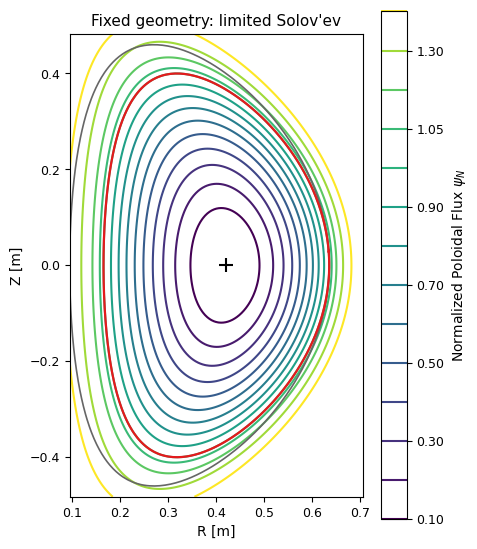

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from vaft.process.equilibrium import solovev_example
from vaft.process.profile import (
    analytic_hmode_itb_state, analytic_hmode_state, analytic_itb_state, analytic_lmode_state,
    evaluate_analytic_profile, evaluate_plasma_state, project_plasma_state,
)
from vaft.plot import plot_plasma_state_projection, plot_solovev_equilibrium

# 1. One VEST-like analytic geometry (R0 = 0.4 m, A = 1.7, kappa = 1.7, delta = 0.35), COCOS 11.
geometry = solovev_example("limited", resolution=129)
fig, ax = plot_solovev_equilibrium(geometry, x_points=False, title="Fixed geometry: limited Solov'ev")
fig.set_size_inches(4.2, 5.6)
plt.show()

## 2. Smooth L-mode-like state

Each channel is $f(\psi_N) = f_\mathrm{sep} + A\,(1-\psi_N^{\alpha})^{\beta}$ with the axis and
separatrix values holding exactly. The pressure is not an input: it is $e\,n\,T$ of the stored
profiles, with $n_i$ from quasi-neutrality (`z_eff = 1` here, so $n_i = n_e$).

In [ ]:
common = dict(ne_sep=2.0e18, te_sep=10.0, ti_sep=8.0)
lmode = analytic_lmode_state(ne_axis=1.2e19, te_axis=150.0, ti_axis=80.0, **common)

print(f"{'':6s}{'axis':>12s}{'separatrix':>12s}")
for name in ("n_e", "T_e", "T_i", "p_total"):
    values = getattr(lmode, name)
    print(f"{name:6s}{values[0]:12.4g}{values[-1]:12.4g}   [{lmode.unit(name)}]")
print("p = e n_e T_e + e n_i T_i reproduced:",
      np.allclose(lmode.p_total, 1.602176634e-19 * (lmode.n_e * lmode.T_e + lmode.n_i * lmode.T_i)))

              axis  separatrix
n_e        1.2e+19       2e+18   [m^-3]
T_e            150          10   [eV]
T_i             80           8   [eV]
p_total       442.2       5.768   [Pa]
p = e n_e T_e + e n_i T_i reproduced: True


## 3. Add an edge pedestal: H-mode-like state

The pedestal is a Groebner tanh step with the **full-width** convention of
`modified_tanh_profile`: centre `pedestal_position`, knee (pedestal top) at
`position − width/2`, foot at `position + width/2`. The requested top value holds exactly at
the knee; the core amplitude and the step height are solved for, so the axis and separatrix
values still hold.

In [ ]:
pedestal = dict(pedestal_position=0.93, pedestal_width=0.05)
hmode = analytic_hmode_state(ne_axis=1.5e19, ne_ped=1.1e19, te_axis=250.0, te_ped=80.0,
                             ti_axis=120.0, ti_ped=50.0, **common, **pedestal)

knee = pedestal["pedestal_position"] - pedestal["pedestal_width"] / 2
for name in ("n_e", "T_e", "T_i"):
    prof = hmode.profiles[name]
    print(f"{name}: axis {evaluate_analytic_profile(prof, 0.0):.4g}, "
          f"knee (psi_N = {knee:.3f}) {evaluate_analytic_profile(prof, knee):.4g}, "
          f"separatrix {evaluate_analytic_profile(prof, 1.0):.4g}  "
          f"(step height {prof.pedestal.height:.4g}, core amplitude {prof.core_amplitude:.4g}) [{prof.unit}]")

n_e: axis 1.5e+19, knee (psi_N = 0.905) 1.1e+19, separatrix 2e+18  (step height 1.013e+19, core amplitude 2.872e+18) [m^-3]
T_e: axis 250, knee (psi_N = 0.905) 80, separatrix 10  (step height 73.99, core amplitude 166) [eV]
T_i: axis 120, knee (psi_N = 0.905) 50, separatrix 8  (step height 45.5, core amplitude 66.5) [eV]


## 4. Move the barrier inside: ITB-like state

The same step, placed at an interior $\psi_N$, is an internal transport barrier. Its strength
is the **whole step amplitude** (`*_itb_height`): the profile's axis side sits that much above
its separatrix side because of the step. Only about $\tanh 1 \approx 0.76$ of it is crossed between the
knee and the foot. The axis value is held, so a barrier
alone steepens the profile at its centre and flattens it elsewhere; raising the core is a
separate choice, made here by raising the axis values. Each channel may have its own barrier
position and width (a mapping keyed by `n_e`/`T_e`/`T_i`), or none (height zero).

In [ ]:
itb_heights = dict(ne_itb_height=4.0e18, te_itb_height=150.0, ti_itb_height=70.0)
itb = analytic_itb_state(ne_axis=1.8e19, te_axis=350.0, ti_axis=180.0, **common, **itb_heights,
                         itb_position=0.3, itb_width=0.08)

# Independent channels: T_i barrier further out and wider, no density barrier.
itb_channels = analytic_itb_state(ne_axis=1.8e19, te_axis=350.0, ti_axis=180.0, **common,
                                  ne_itb_height=0.0, te_itb_height=150.0, ti_itb_height=70.0,
                                  itb_position={"n_e": 0.3, "T_e": 0.3, "T_i": 0.45},
                                  itb_width={"n_e": 0.08, "T_e": 0.06, "T_i": 0.12})
for name, prof in itb_channels.profiles.items():
    print(name, "ITB:", None if prof.itb is None else (prof.itb.position, prof.itb.width, prof.itb.height))

n_e ITB: None
T_e ITB: (0.3, 0.06, 150.0)
T_i ITB: (0.45, 0.12, 70.0)


## 5. Combine: H-mode + ITB

Smooth core + internal barrier + edge pedestal, composed by the same function. The knee value
of the pedestal is still exact.

In [ ]:
hmode_itb = analytic_hmode_itb_state(ne_axis=2.0e19, ne_ped=1.1e19, te_axis=400.0, te_ped=80.0,
                                     ti_axis=200.0, ti_ped=50.0, **common, **pedestal, **itb_heights,
                                     itb_position=0.3, itb_width=0.08)
print("T_e at the knee:", evaluate_plasma_state(hmode_itb, knee, "T_e"), "eV")
states = [lmode, hmode, itb, hmode_itb]

T_e at the knee: 80.0 eV


## 6. Compare the four states on the fixed geometry

Profiles and the total-pressure gradient against $\psi_N$. The gradient is analytic (the
product rule on the kernels' derivatives), so the pedestal and ITB show up as localized
negative peaks at the barrier centres.

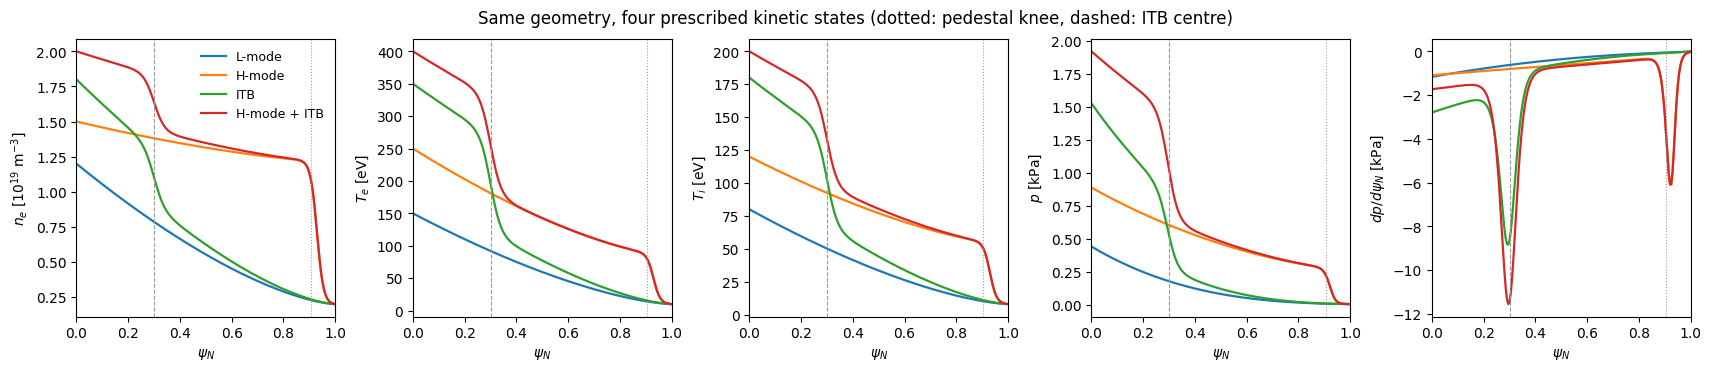

In [ ]:
quantities = [("n_e", r"$n_e$ [$10^{19}$ m$^{-3}$]", 1e-19), ("T_e", r"$T_e$ [eV]", 1.0),
              ("T_i", r"$T_i$ [eV]", 1.0), ("p_total", r"$p$ [kPa]", 1e-3),
              ("dp_total_dpsi_norm", r"$dp/d\psi_N$ [kPa]", 1e-3)]
fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), constrained_layout=True)
for ax, (name, label, scale) in zip(axes, quantities):
    for state in states:
        ax.plot(state.psi_norm, getattr(state, name) * scale, label=state.label, lw=1.6)
    ax.set_xlabel(r"$\psi_N$")
    ax.set_ylabel(label)
    ax.set_xlim(0, 1)
    ax.axvline(knee, color="0.6", lw=0.8, ls=":")
    ax.axvline(0.3, color="0.6", lw=0.8, ls="--")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Same geometry, four prescribed kinetic states (dotted: pedestal knee, dashed: ITB centre)")
plt.show()

The barrier parameters have explicit meanings. Below, the $T_e$ channels of the
independent-channel ITB state and of the H-mode state are drawn with the barrier centre and
its knee/foot marked: the steepest gradient sits at the centre, and the full width spans from
the knee to the foot, where an isolated tanh step is at 88 % and 12 % of its amplitude, so the
change across the band is about 76 % of the amplitude.

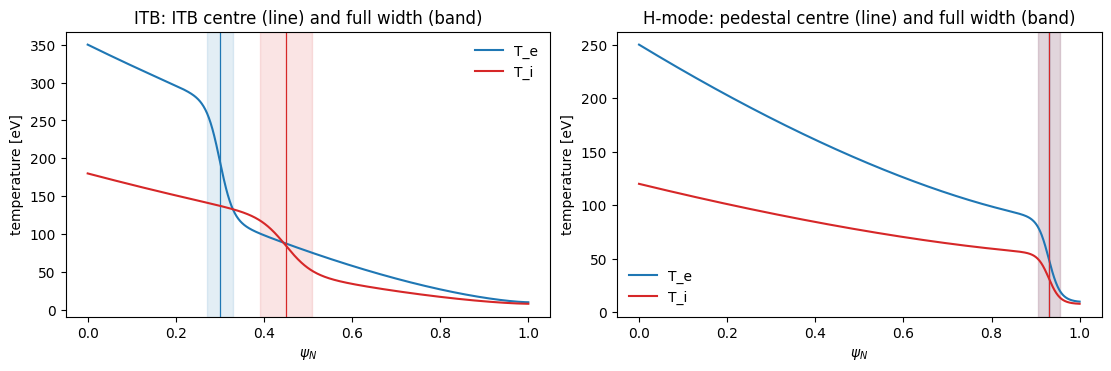

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
x = np.linspace(0, 1, 1001)
for ax, (state, which, word) in zip(axes, ((itb_channels, "itb", "ITB"), (hmode, "pedestal", "pedestal"))):
    for name, color in (("T_e", "C0"), ("T_i", "C3")):
        prof = state.profiles[name]
        step = getattr(prof, which)
        ax.plot(x, evaluate_analytic_profile(prof, x), color=color, label=name)
        if step is not None:
            ax.axvline(step.position, color=color, lw=0.9)
            ax.axvspan(step.knee, step.foot, color=color, alpha=0.12)
    ax.set_xlabel(r"$\psi_N$")
    ax.set_ylabel("temperature [eV]")
    ax.set_title(f"{state.label}: {word} centre (line) and full width (band)")
    ax.legend(frameon=False)
plt.show()

## 7. Project onto $(R, Z)$

`project_plasma_state` evaluates the state's analytic definition at every grid point's
$\psi_N = (\psi-\psi_\mathrm{axis})/(\psi_\mathrm{boundary}-\psi_\mathrm{axis})$ — a ratio in which
the COCOS sign and the Wb vs Wb/rad factor cancel — and leaves points outside the LCFS as NaN
(`outside="edge"` fills them with the separatrix value instead). The maps are drawn by the
canonical `vaft.plot.plot_plasma_state_projection`.

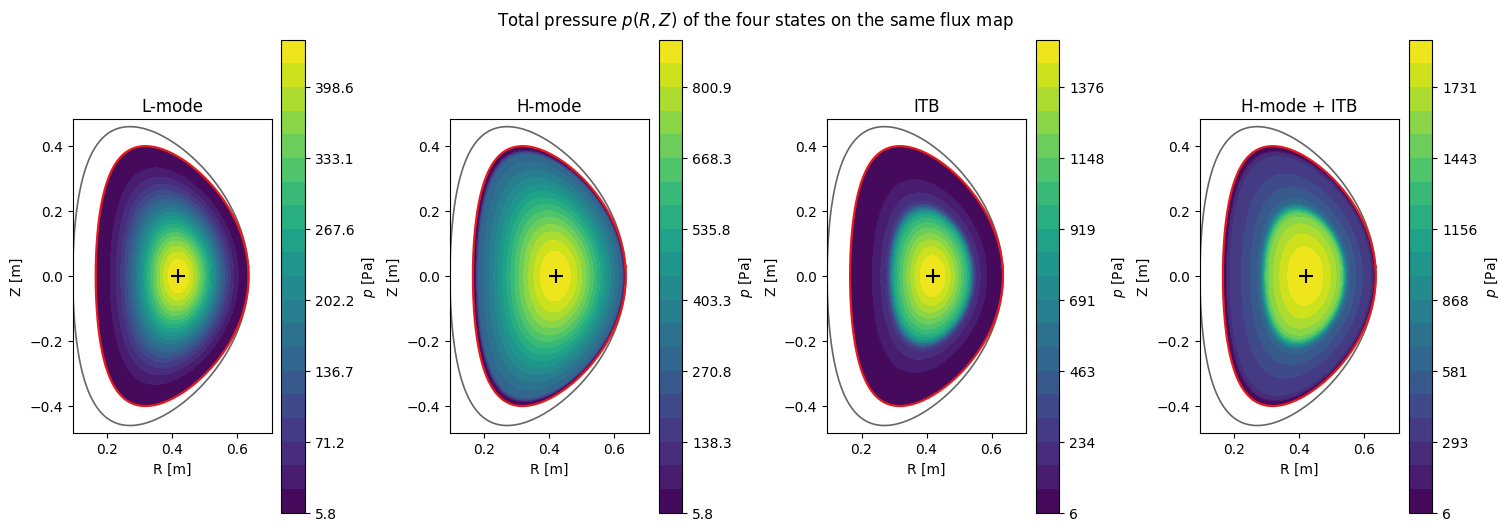

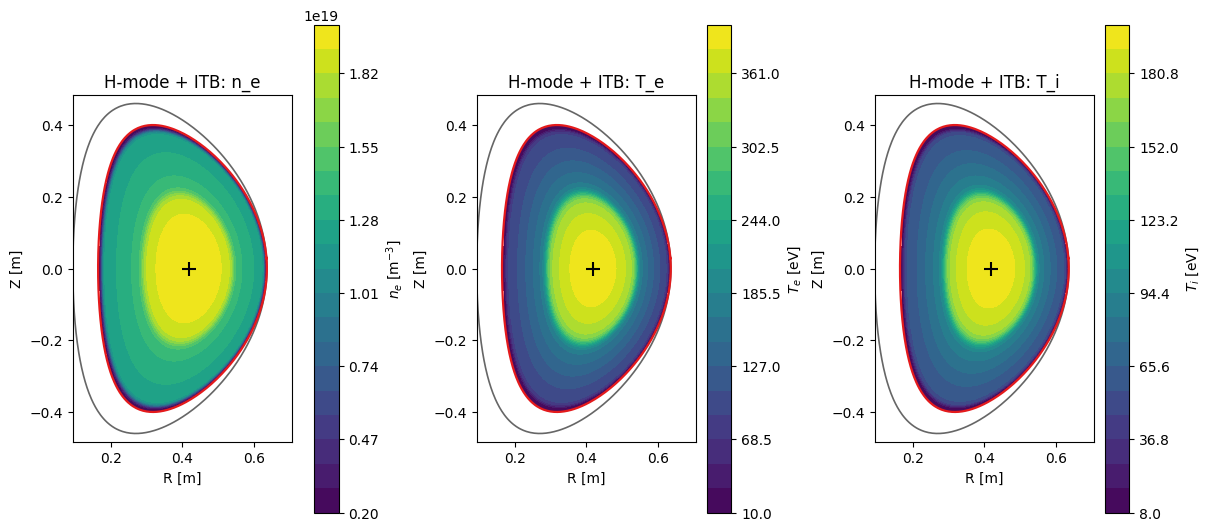

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5.2), constrained_layout=True)
for ax, state in zip(axes, states):
    plot_plasma_state_projection(state, geometry, "p_total", ax=ax, title=state.label)
fig.suptitle(r"Total pressure $p(R, Z)$ of the four states on the same flux map")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 5.2), constrained_layout=True)
for ax, name in zip(axes, ("n_e", "T_e", "T_i")):
    plot_plasma_state_projection(hmode_itb, geometry, name, ax=ax, title=f"H-mode + ITB: {name}")
plt.show()

The 1-D definition is independent of the geometry: projecting the same state onto a
different compatible geometry (here a lower single-null Solov'ev) changes where each value
lands, not the profile.

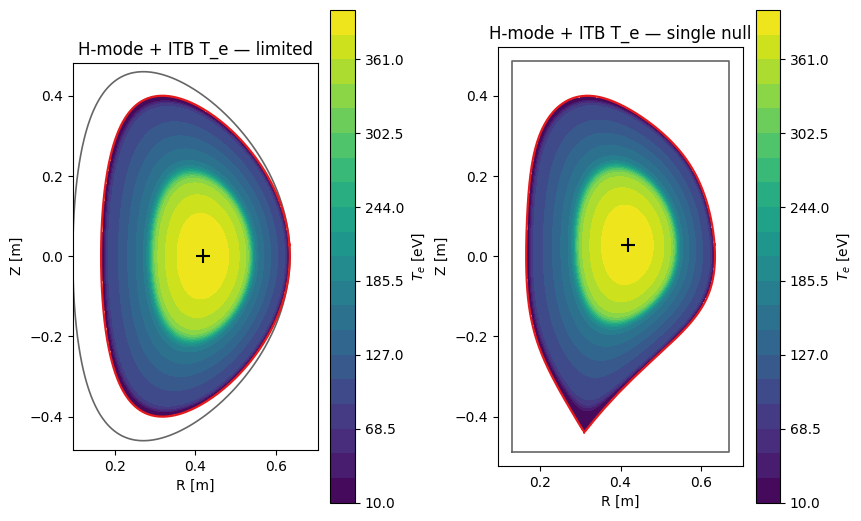

In [ ]:
other = solovev_example("single_null", resolution=129)
fig, axes = plt.subplots(1, 2, figsize=(8.5, 5.4), constrained_layout=True)
for ax, eq, title in ((axes[0], geometry, "limited"), (axes[1], other, "single null")):
    plot_plasma_state_projection(hmode_itb, eq, "T_e", ax=ax, title=f"H-mode + ITB T_e — {title}")
plt.show()

## 8. These states are not Grad–Shafranov self-consistent

The Solov'ev geometry was solved for its own sources: $p'$ constant, i.e. a pressure **linear**
in $\psi_N$. Placing a prescribed $p(\psi_N)$ on its flux map does not change the map, so the
force balance $\nabla p = \mathbf{J}\times\mathbf{B}$ that produced those flux surfaces no longer
holds for the new pressure. The comparison below normalizes both to their axis values.

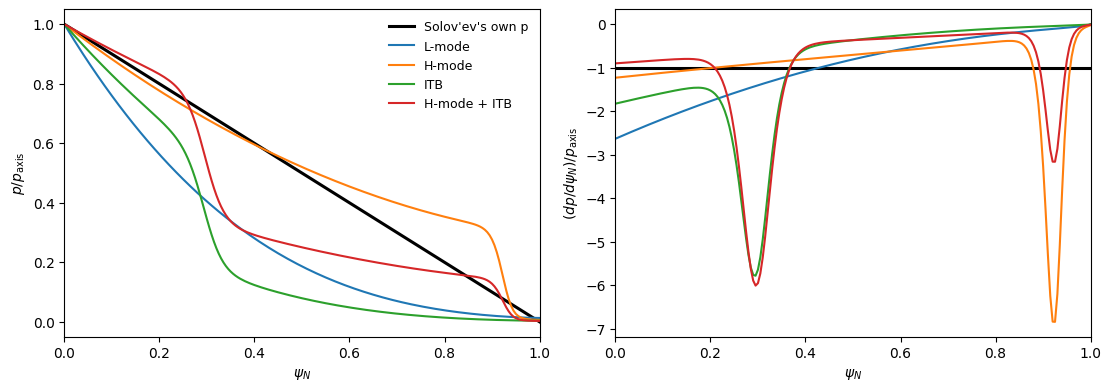

recorded on every state: {'L-mode': False, 'H-mode': False, 'ITB': False, 'H-mode + ITB': False}


In [ ]:
psi_n_1d = (geometry.psi_1d - geometry.psi_axis) / (geometry.psi_boundary - geometry.psi_axis)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].plot(psi_n_1d, geometry.pressure / geometry.pressure[0], "k", lw=2.2, label="Solov'ev's own p")
for state in states:
    axes[0].plot(state.psi_norm, state.p_total / state.p_total[0], label=state.label)
axes[0].set_ylabel(r"$p / p_\mathrm{axis}$")
dp_solovev = np.gradient(geometry.pressure, psi_n_1d) / geometry.pressure[0]
axes[1].plot(psi_n_1d, dp_solovev, "k", lw=2.2, label="Solov'ev (constant p')")
for state in states:
    axes[1].plot(state.psi_norm, state.dp_total_dpsi_norm / state.p_total[0], label=state.label)
axes[1].set_ylabel(r"$(dp/d\psi_N)/p_\mathrm{axis}$")
for ax in axes:
    ax.set_xlabel(r"$\psi_N$")
    ax.set_xlim(0, 1)
axes[0].legend(frameon=False, fontsize=9)
plt.show()
print("recorded on every state:", {s.label: s.metadata["grad_shafranov_consistent"] for s in states})

## 9. The next layer: making a state self-consistent

The prescribed profiles answer *what do these confinement regimes look like on a flux map*.
They leave open: **given these kinetic profiles, what magnetic equilibrium do they imply?**
That is a new equilibrium solve, owned elsewhere:

- CHEASE fixed-boundary refinement with a prescribed pressure — `equilibrium_refinement_using_chease.ipynb`
  and `fixed_boundary_parametric_scan_using_chease.ipynb`;
- forward free-boundary solves — `forward_equilibrium_using_TokaMaker.ipynb`, `forward_equilibrium_using_TES.ipynb`;
- equilibrium–kinetic iteration (#123) and equilibrium synthesis (#120);
- the general synthetic kinetic-profile framework (#122), for which these presets are building
  blocks; `AnalyticPlasmaState.to_kinetic_profiles()` hands a state to the package's
  kinetic-profile container.

Out of scope here by design: pedestal prediction (EPED), bootstrap current (#559),
peeling–ballooning stability, and ITB formation physics.